# 01 — Análise Exploratória de Dados (EDA)
**TC1: Rede Neural para Previsão de Churn — FIAP Pós-Tech MLOps**

Este notebook cobre as seções 2 a 8 da Etapa 1:
- Carregamento e limpeza dos dados (`src/data/loader.py`)
- Análise de qualidade, distribuição e data readiness
- Análise exploratória completa com gráficos
- Análise de custo FP vs FN

**Saída:** `telco_treated.csv` — usado pelo `02_baselines.ipynb`

---

## 0. Setup

In [1]:
!pip install mlflow pandera --quiet

import sys, os
sys.path.append('..')  # permite importar src/

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
COLORS = {'no_churn': '#4C72B0', 'churn': '#DD8452'}
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (11, 5)})

print('✅ Setup concluído | Seed:', SEED)

'pip' nÃ£o Ã© reconhecido como um comando interno
ou externo, um programa operÃ¡vel ou um arquivo em lotes.


✅ Setup concluído | Seed: 42


---
## 1. Carregamento e Limpeza

> Lógica encapsulada em `src/data/loader.py`

In [2]:
from src.data.loader import load_raw

DATA_PATH = '../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = load_raw(DATA_PATH)

print(f'Shape: {df.shape}')
df.head()

Shape: (7043, 22)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_bin
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


---
## 2. Qualidade dos Dados

In [4]:
missing = df.isnull().sum()
display(pd.DataFrame({
    'nulos': missing,
    'pct (%)': (missing / len(df) * 100).round(2)
})[missing > 0] if missing.sum() > 0 else pd.DataFrame({'resultado': ['✅ Nenhum valor nulo']}))

print(f'Duplicatas: {df.duplicated().sum()}')
print(f'\nEstatísticas numéricas:')
display(df[['tenure','MonthlyCharges','TotalCharges']].describe().round(2))

,resultado
0,✅ Nenhum valor nulo


Duplicatas: 0

Estatísticas numéricas:


,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00
mean,32.37,64.76,2281.92
std,24.56,30.09,2265.27
min,0.00,18.25,18.80
25%,9.00,35.50,402.22
50%,29.00,70.35,1397.48
75%,55.00,89.85,3786.60
max,72.00,118.75,8684.80


---
## 3. Distribuição do Target

,contagem,proporção (%)
Churn,,
No,5174,73.46
Yes,1869,26.54


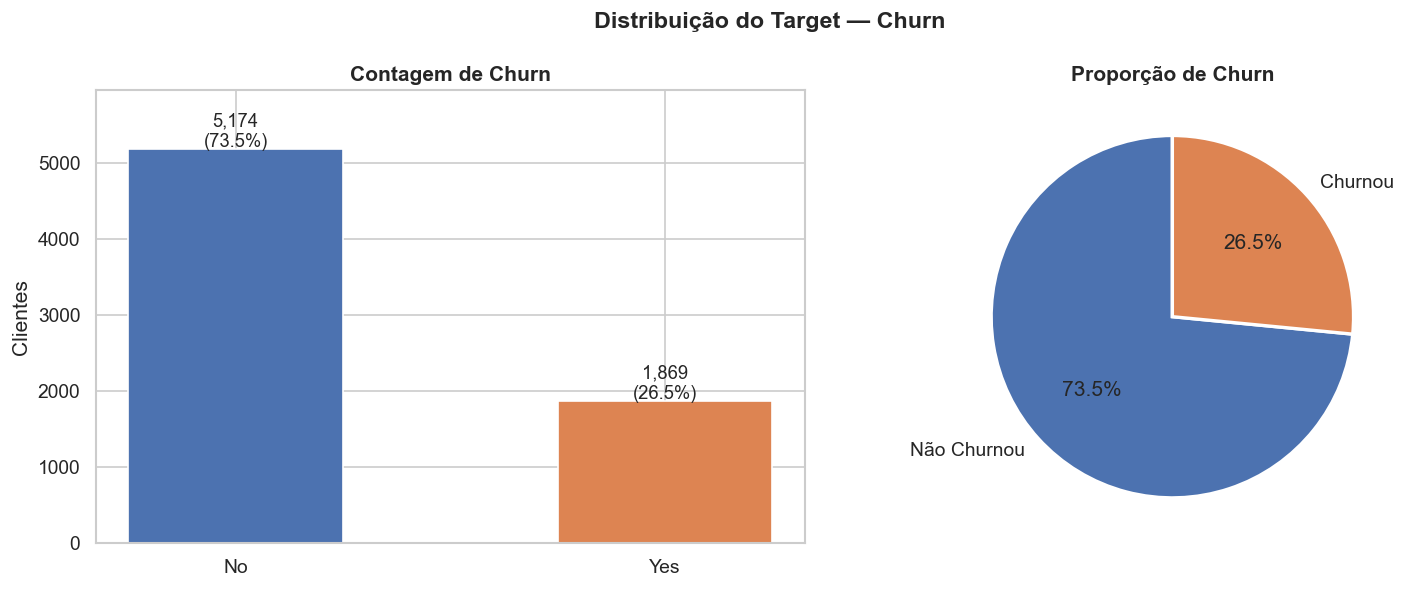


⚠️  DESBALANCEAMENTO: 26.5% de churn.
📌 Estratégia: class_weight="balanced" + threshold tuning.


In [5]:
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100
display(pd.DataFrame({'contagem': churn_counts, 'proporção (%)': churn_pct.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bars = axes[0].bar(churn_counts.index, churn_counts.values,
                   color=[COLORS['no_churn'], COLORS['churn']], edgecolor='white', width=0.5)
for bar, val in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=11)
axes[0].set_title('Contagem de Churn', fontweight='bold')
axes[0].set_ylabel('Clientes')
axes[0].set_ylim(0, churn_counts.max() * 1.15)

axes[1].pie(churn_counts, labels=['Não Churnou', 'Churnou'],
            autopct='%1.1f%%', colors=[COLORS['no_churn'], COLORS['churn']],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporção de Churn', fontweight='bold')

plt.suptitle('Distribuição do Target — Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n⚠️  DESBALANCEAMENTO: {churn_pct["Yes"]:.1f}% de churn.')
print('📌 Estratégia: class_weight="balanced" + threshold tuning.')

---
## 4. Variáveis Numéricas

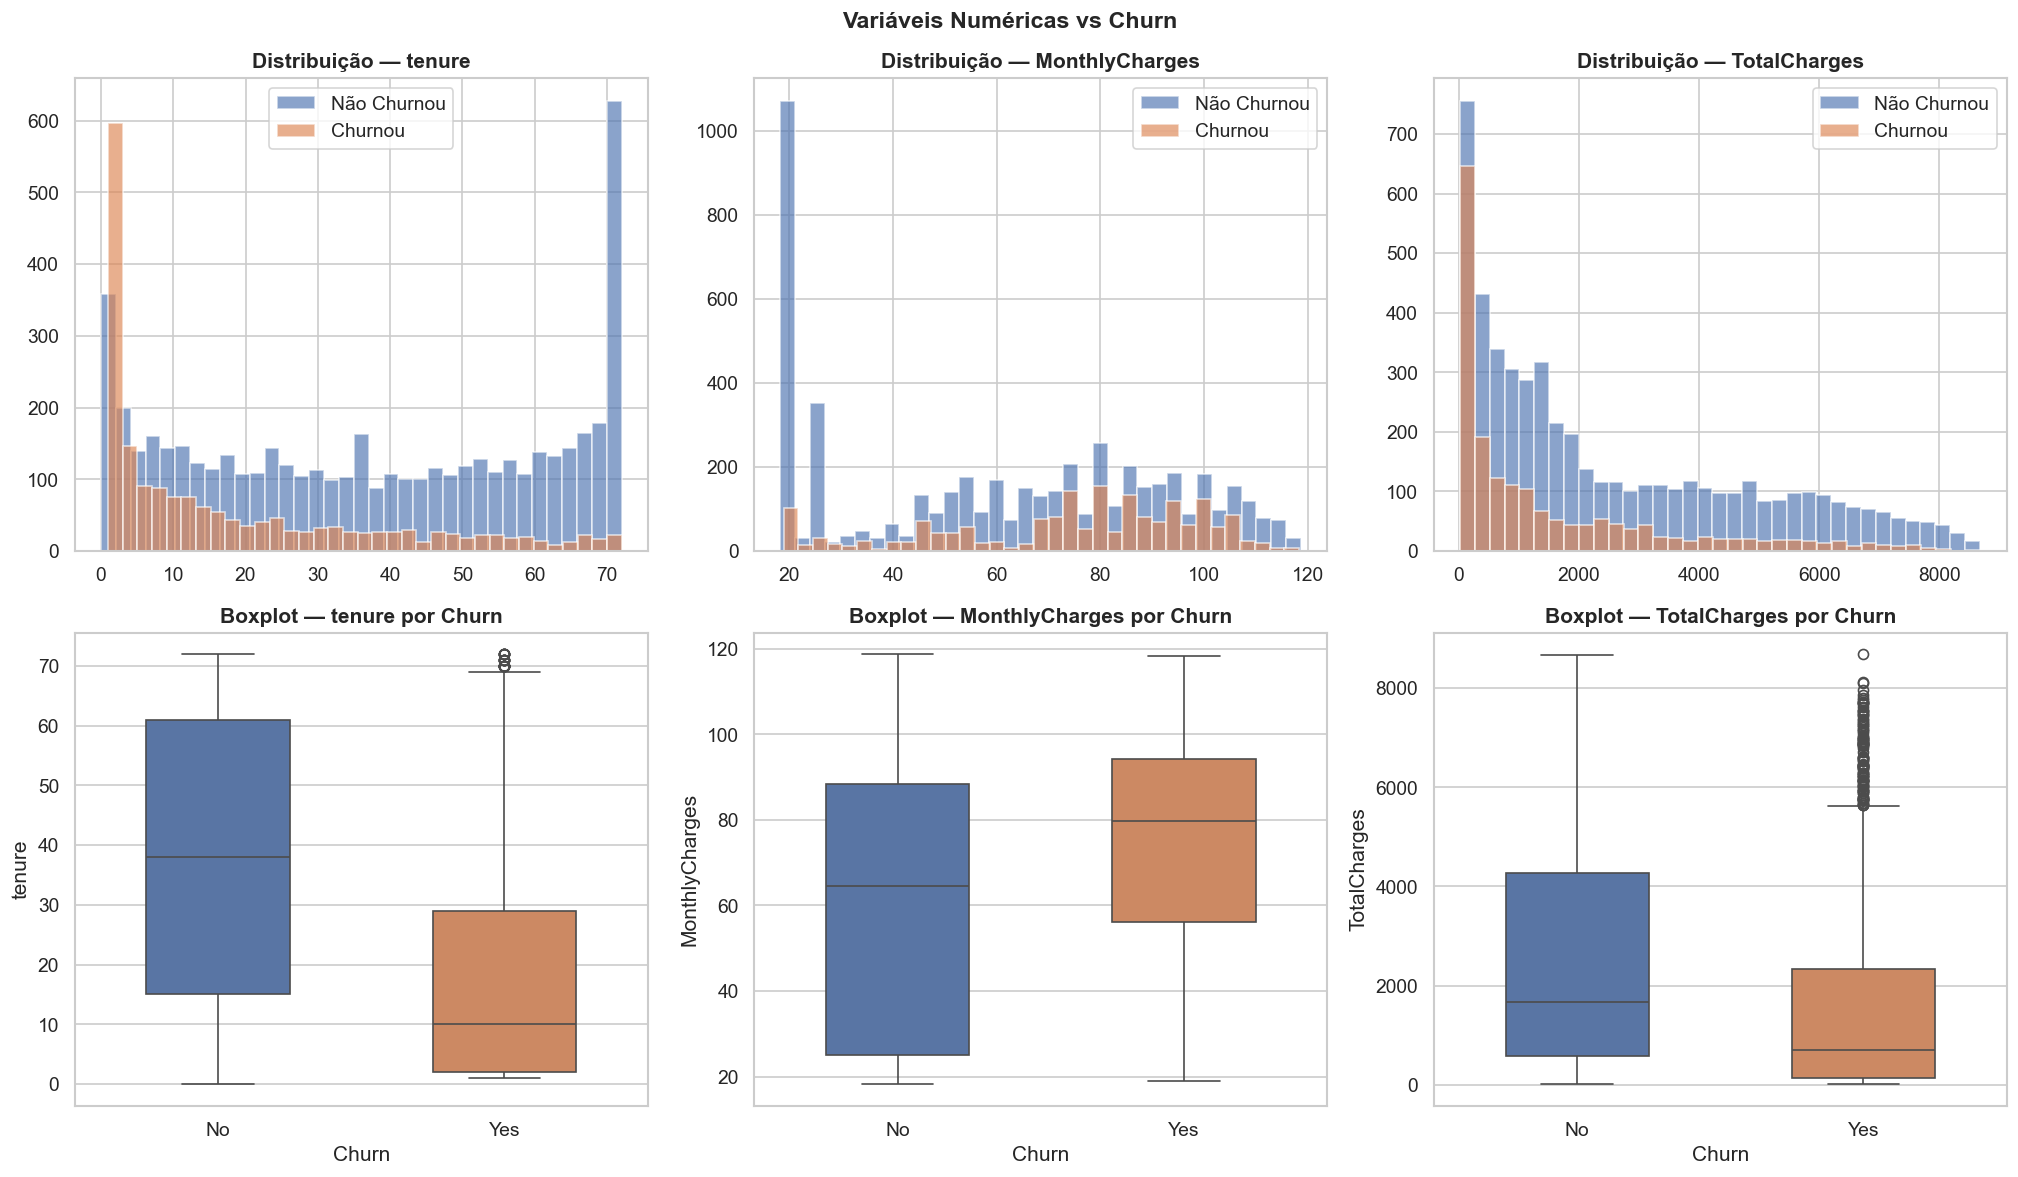

tenure               MonthlyCharges               TotalCharges           \
        mean median    std           mean median    std         mean   median   
Churn                                                                           
No     37.57   38.0  24.11          61.27  64.43  31.09      2552.88  1679.52   
Yes    17.98   10.0  19.53          74.44  79.65  24.67      1531.80   703.55   

                
           std  
Churn           
No     2327.59  
Yes    1890.82

In [6]:
NUM_COLS = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

for i, col in enumerate(NUM_COLS):
    for churn_val, color, label in zip(
        ['No', 'Yes'], [COLORS['no_churn'], COLORS['churn']], ['Não Churnou', 'Churnou']
    ):
        axes[0, i].hist(df[df['Churn'] == churn_val][col],
                        bins=35, alpha=0.65, label=label, color=color, edgecolor='white')
    axes[0, i].set_title(f'Distribuição — {col}', fontweight='bold')
    axes[0, i].legend()

    sns.boxplot(x='Churn', y=col, data=df,
                palette=[COLORS['no_churn'], COLORS['churn']], ax=axes[1, i], width=0.5)
    axes[1, i].set_title(f'Boxplot — {col} por Churn', fontweight='bold')

plt.suptitle('Variáveis Numéricas vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

display(df.groupby('Churn')[NUM_COLS].agg(['mean', 'median', 'std']).round(2))

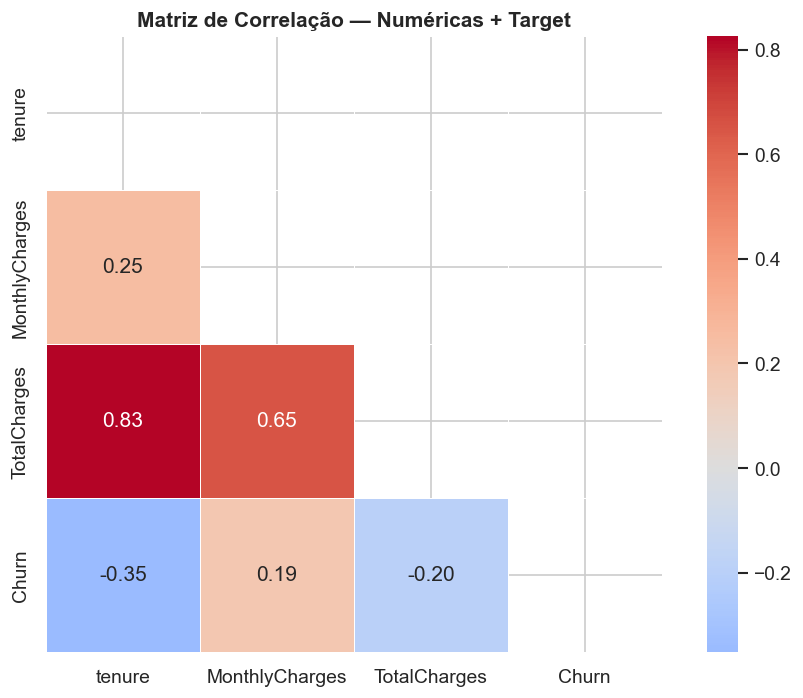

📌 tenure × Churn = -0.35: clientes novos churnam mais
📌 MonthlyCharges × Churn = +0.19: planos caros churnam mais


In [7]:
df_corr = df[NUM_COLS].copy()
df_corr['Churn'] = df['Churn_bin']

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(df_corr.corr(), dtype=bool))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, mask=mask)
plt.title('Matriz de Correlação — Numéricas + Target', fontweight='bold')
plt.tight_layout()
plt.show()

print('📌 tenure × Churn = -0.35: clientes novos churnam mais')
print('📌 MonthlyCharges × Churn = +0.19: planos caros churnam mais')

---
## 5. Variáveis Categóricas

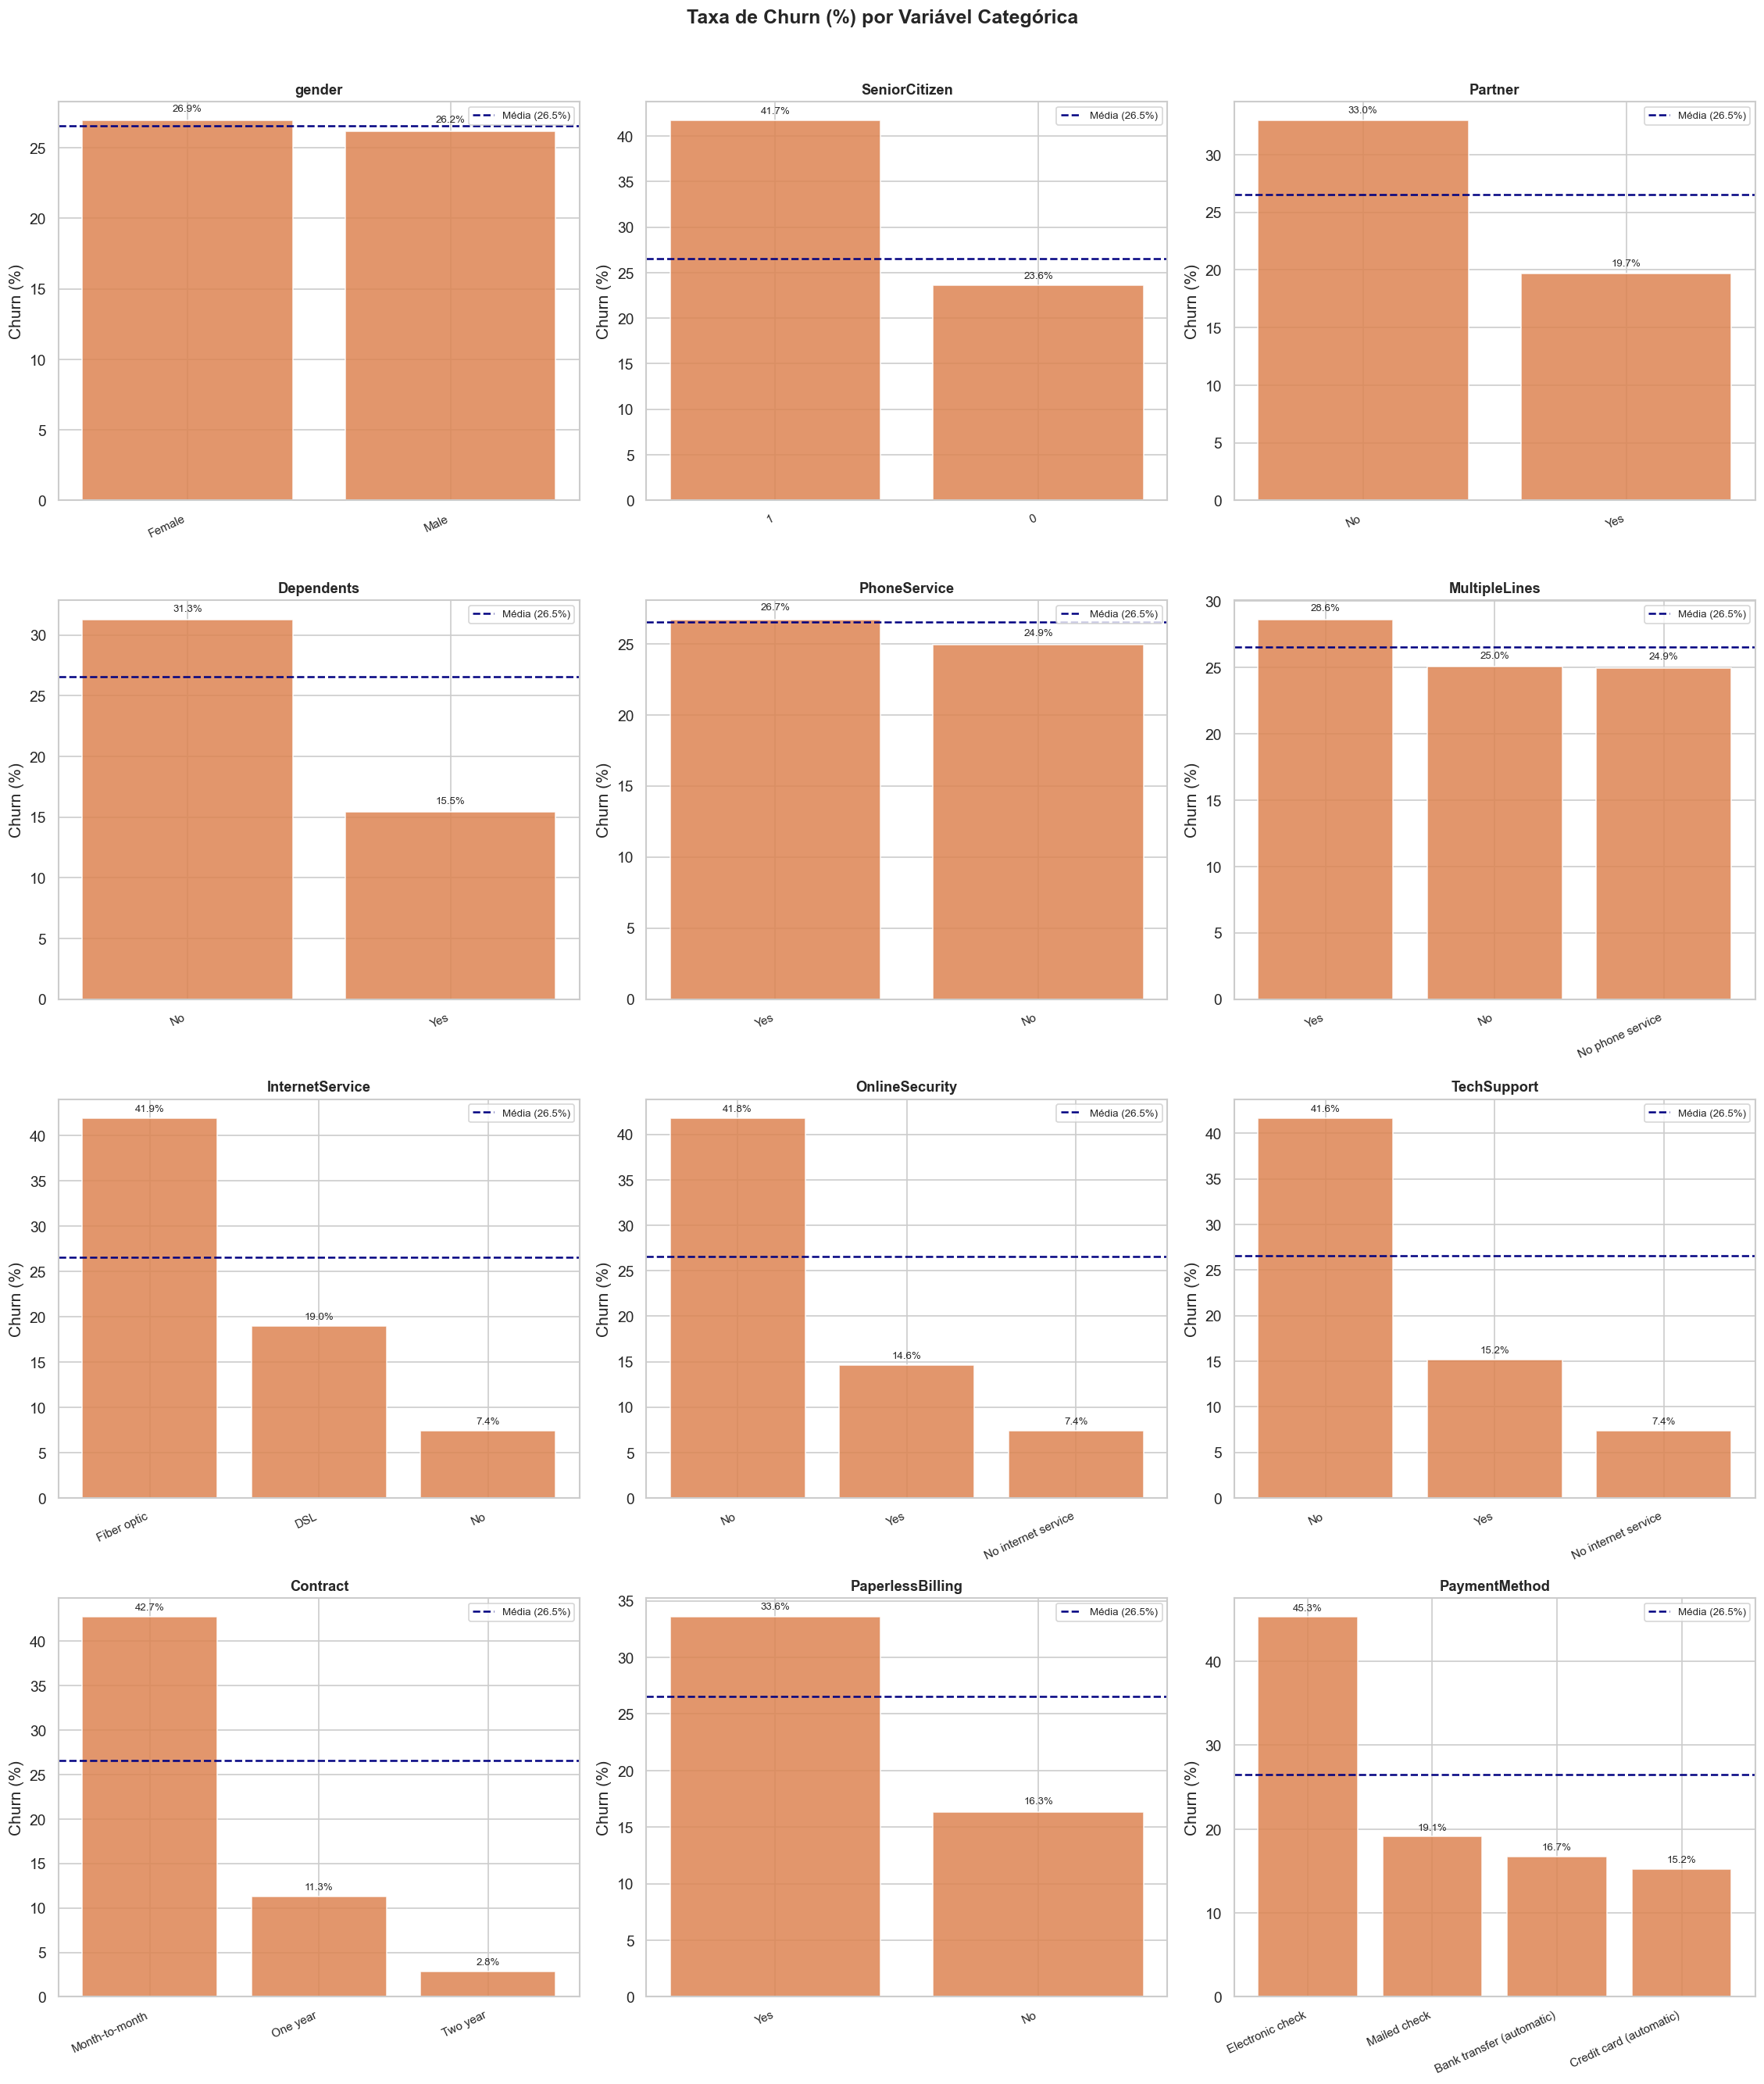

In [8]:
CAT_COLS = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'TechSupport', 'Contract',
    'PaperlessBilling', 'PaymentMethod'
]
media_geral = df['Churn_bin'].mean() * 100

fig, axes = plt.subplots(4, 3, figsize=(19, 22))
axes = axes.flatten()

for i, col in enumerate(CAT_COLS):
    churn_rate = (df.groupby(col)['Churn_bin'].mean() * 100).sort_values(ascending=False)
    bars = axes[i].bar(range(len(churn_rate)), churn_rate.values,
                       color=COLORS['churn'], edgecolor='white', alpha=0.85)
    axes[i].set_xticks(range(len(churn_rate)))
    axes[i].set_xticklabels(churn_rate.index, rotation=25, ha='right', fontsize=9)
    axes[i].set_title(f'{col}', fontweight='bold', fontsize=11)
    axes[i].set_ylabel('Churn (%)')
    axes[i].axhline(y=media_geral, color='navy', linestyle='--',
                    linewidth=1.5, label=f'Média ({media_geral:.1f}%)')
    axes[i].legend(fontsize=8)
    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

plt.suptitle('Taxa de Churn (%) por Variável Categórica', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 6. Insights de Destaque

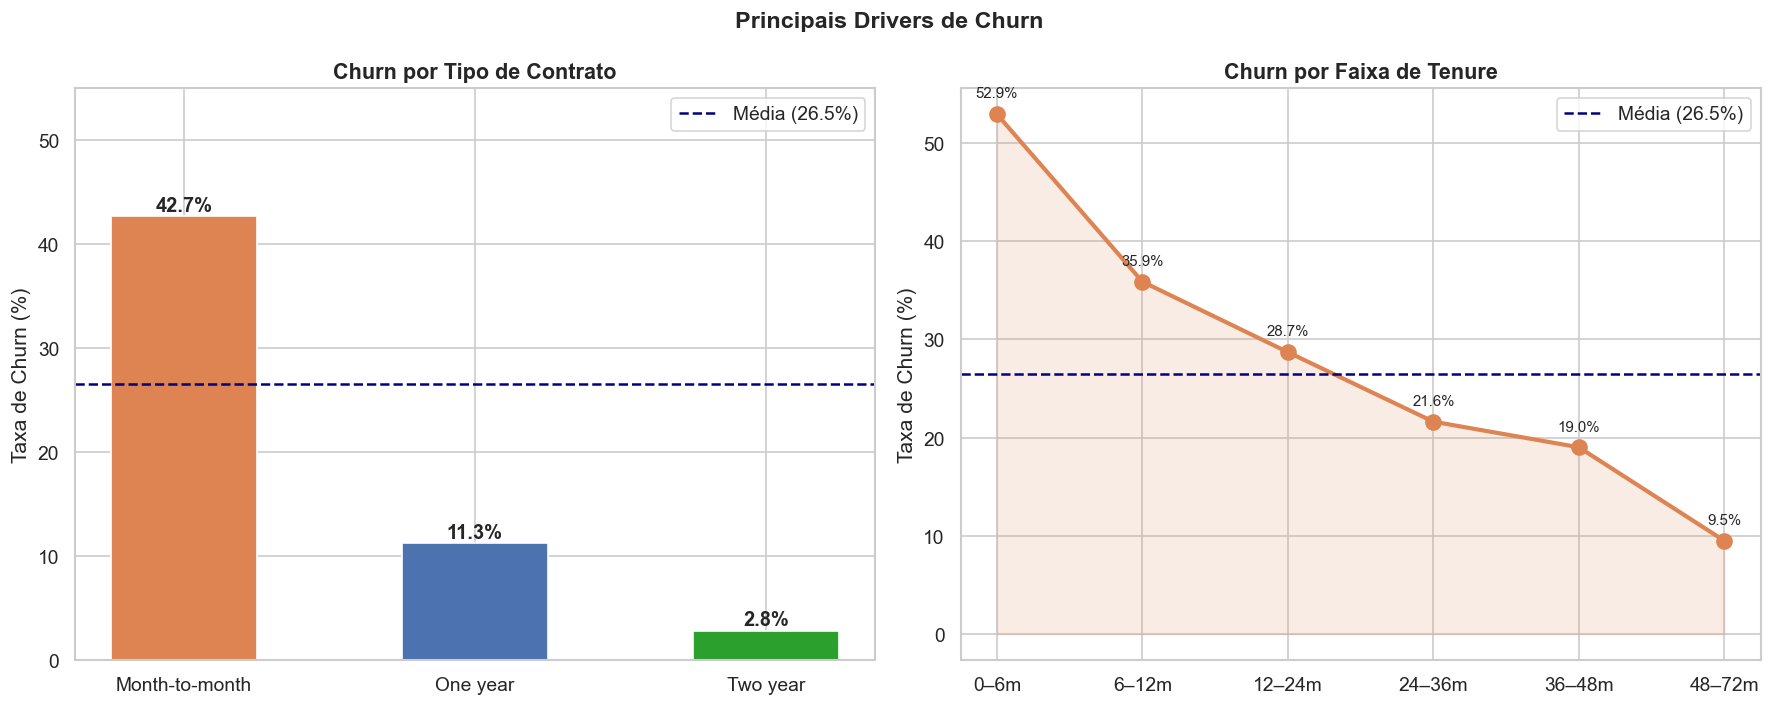

📌 Contratos mensais: ~42% churn vs ~3% bianuais
📌 Clientes 0–6 meses: ~48% churn — período crítico


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

contract_churn = df.groupby('Contract')['Churn_bin'].mean() * 100
bars = axes[0].bar(contract_churn.index, contract_churn.values,
                   color=[COLORS['churn'], COLORS['no_churn'], '#2ca02c'],
                   edgecolor='white', width=0.5)
for bar, val in zip(bars, contract_churn.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[0].axhline(y=media_geral, color='navy', linestyle='--', linewidth=1.5,
                label=f'Média ({media_geral:.1f}%)')
axes[0].set_title('Churn por Tipo de Contrato', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Taxa de Churn (%)')
axes[0].set_ylim(0, 55)
axes[0].legend()

df['tenure_bin'] = pd.cut(df['tenure'], bins=[0,6,12,24,36,48,72],
                           labels=['0–6m','6–12m','12–24m','24–36m','36–48m','48–72m'],
                           include_lowest=True)
tenure_churn = df.groupby('tenure_bin', observed=True)['Churn_bin'].mean() * 100
axes[1].plot(tenure_churn.index, tenure_churn.values, marker='o',
             color=COLORS['churn'], linewidth=2.5, markersize=9)
axes[1].fill_between(range(len(tenure_churn)), tenure_churn.values,
                     alpha=0.15, color=COLORS['churn'])
axes[1].axhline(y=media_geral, color='navy', linestyle='--', linewidth=1.5,
                label=f'Média ({media_geral:.1f}%)')
axes[1].set_xticks(range(len(tenure_churn)))
axes[1].set_xticklabels(tenure_churn.index)
axes[1].set_title('Churn por Faixa de Tenure', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Taxa de Churn (%)')
axes[1].legend()
for x, val in enumerate(tenure_churn.values):
    axes[1].annotate(f'{val:.1f}%', (x, val), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=9)

plt.suptitle('Principais Drivers de Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('📌 Contratos mensais: ~42% churn vs ~3% bianuais')
print('📌 Clientes 0–6 meses: ~48% churn — período crítico')

---
## 7. Data Readiness

In [10]:
print('=' * 60)
print('        RELATÓRIO DE DATA READINESS')
print('=' * 60)
print(f'  Volume total:           {len(df):,} registros')
print(f'  Valores nulos:          0 (após correção do TotalCharges)')
print(f'  Duplicatas:             {df.duplicated().sum()}')
print(f'  Desbalanceamento:       {df["Churn_bin"].mean()*100:.1f}% positivos')
print(f'  Variáveis numéricas:    3')
print(f'  Variáveis categóricas:  16')
print('=' * 60)
print('  TRATAMENTOS APLICADOS:')
print('  [✅] TotalCharges convertido para float')
print('  [✅] 11 NaN preenchidos com mediana')
print('  [✅] Target binarizado (Yes→1, No→0)')
print('  [→]  Pipeline sklearn: StandardScaler + OneHotEncoder')
print('  [→]  StratifiedKFold 5 folds na modelagem')
print('=' * 60)

        RELATÓRIO DE DATA READINESS
  Volume total:           7,043 registros
  Valores nulos:          0 (após correção do TotalCharges)
  Duplicatas:             0
  Desbalanceamento:       26.5% positivos
  Variáveis numéricas:    3
  Variáveis categóricas:  16
  TRATAMENTOS APLICADOS:
  [✅] TotalCharges convertido para float
  [✅] 11 NaN preenchidos com mediana
  [✅] Target binarizado (Yes→1, No→0)
  [→]  Pipeline sklearn: StandardScaler + OneHotEncoder
  [→]  StratifiedKFold 5 folds na modelagem


---
## 8. Análise de Custo — FP vs FN

In [11]:
# Premissas ilustrativas — valores reais fornecidos pelo time de negócio
TICKET_MEDIO_MENSAL    = df['MonthlyCharges'].mean()
MESES_RETIDOS          = 6
TAXA_SUCESSO_RETENCAO  = 0.3
CUSTO_CAMPANHA         = 15.0

valor_tp = TICKET_MEDIO_MENSAL * MESES_RETIDOS * TAXA_SUCESSO_RETENCAO
custo_fp = CUSTO_CAMPANHA
custo_fn = TICKET_MEDIO_MENSAL * MESES_RETIDOS

print('=' * 55)
print('  ANÁLISE DE CUSTO — TRADE-OFF FP vs FN')
print('  (premissas ilustrativas)')
print('=' * 55)
print(f'  Ticket médio mensal:  ${TICKET_MEDIO_MENSAL:.2f}')
print(f'  💰 Ganho por TP:      ${valor_tp:.2f}')
print(f'  💸 Custo por FP:      ${custo_fp:.2f}')
print(f'  🔥 Custo por FN:      ${custo_fn:.2f}')
print(f'  Razão FN/FP:          {custo_fn/custo_fp:.1f}x')
print()
print('  📌 FN é ~25x mais caro que FP.')
print('  → Priorizar RECALL ≥ 0.70.')
print('=' * 55)

  ANÁLISE DE CUSTO — TRADE-OFF FP vs FN
  (premissas ilustrativas)
  Ticket médio mensal:  $64.76
  💰 Ganho por TP:      $116.57
  💸 Custo por FP:      $15.00
  🔥 Custo por FN:      $388.57
  Razão FN/FP:          25.9x

  📌 FN é ~25x mais caro que FP.
  → Priorizar RECALL ≥ 0.70.


---
## 9. Salvar dataset tratado

In [12]:
import os
os.makedirs('../data/processed', exist_ok=True)
df.to_csv('../data/processed/telco_treated.csv', index=False)
print('✅ Salvo em data/processed/telco_treated.csv')
print(f'   Shape: {df.shape}')

✅ Salvo em data/processed/telco_treated.csv
   Shape: (7043, 23)
